In [18]:
import numpy as np
import matplotlib.pyplot as plt
import lib_debug

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


$$
f_1(x_1,x_2)
=
-\left[
1.25
\exp\left(
-\frac{(x_1-0.20)^2+(x_2-0.20)^2}{2(0.035)^2}
\right)
+
\exp\left(
-\frac{(x_1-0.72)^2+(x_2-0.72)^2}{2(0.13)^2}
\right)
\right].
$$

$$
f_2(x_1,x_2)
=
f_1(x_1,x_2)
+
0.20
\begin{cases}
0,
& x_1 \le 0.42,\\[6pt]
\left(\dfrac{x_1-0.42}{0.20}\right)^2
\left[
3
-
2\left(\dfrac{x_1-0.42}{0.20}\right)
\right],
& 0.42 < x_1 < 0.62,\\[12pt]
1,
& x_1 \ge 0.62.
\end{cases}
$$

In [23]:
# -------------------- Synthetic function 3D projection plots --------------------
# The synthetic functions are implemented as minimization objectives in lib_debug.py.
# Switch the function and scatter points by comment-in / comment-out.


def _as_2d_points(points):
    """Return points as an (n, 2) array, or None when no points are provided."""
    if points is None:
        return None
    points = np.asarray(points, dtype=float)
    if points.size == 0:
        return None
    return points.reshape(-1, 2)


def plot_synthetic_function_3d(
    function,
    n_grid=121,
    initial_points=None,
    exploration_points=None,
    x_initial=None,
    y_initial=None,
):
    """Plot a 3D surface and a 2D projection with an optional BO search trace.

    initial_points can be an (n, 2) array. For a single initial coordinate, pass
    x_initial and y_initial and it will be connected with the exploration points.
    """
    x1 = np.linspace(0.0, 1.0, n_grid)
    x2 = np.linspace(0.0, 1.0, n_grid)
    X1, X2 = np.meshgrid(x1, x2)
    X = np.stack([X1, X2], axis=-1)
    Z = function(X)

    z_min = float(np.min(Z))
    z_max = float(np.max(Z))
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection="3d")
    surface = ax.plot_surface(X1, X2, Z, cmap="viridis", linewidth=0, antialiased=True, alpha=0.88)
    ax.contour(X1, X2, Z, zdir="z", offset=z_min, cmap="viridis", levels=20)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("f(x)")
    ax.set_zlim(z_min, z_max)
    fig.colorbar(surface, ax=ax, shrink=0.65, pad=0.1)
    plt.tight_layout()

    fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=80)
    cont = ax.contourf(X1, X2, Z, levels=40, cmap="viridis")
    ax.contour(X1, X2, Z, levels=12, colors="white", linewidths=0.5, alpha=0.6)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(cont, ax=ax)
    ax.axhline(0, color="white", linestyle="--", linewidth=1.0)
    ax.axvline(0, color="white", linestyle="--", linewidth=1.0)

    if initial_points is None and x_initial is not None and y_initial is not None:
        initial_points = np.column_stack((np.ravel(x_initial), np.ravel(y_initial)))
    initial_points = _as_2d_points(initial_points)
    exploration_points = _as_2d_points(exploration_points)
    trace_parts = [points for points in (initial_points, exploration_points) if points is not None]
    if trace_parts:
        trace_points = np.vstack(trace_parts)
        ax.plot(
            trace_points[:, 0],
            trace_points[:, 1],
            color="black",
            linestyle=":",
            linewidth=0.8,
            label="search trajectory",
            zorder=4,
        )
    if initial_points is not None:
        ax.scatter(
            initial_points[:, 0],
            initial_points[:, 1],
            color="red",
            s=35,
            marker="o",
            label="initial points",
            zorder=5,
        )
    if exploration_points is not None:
        ax.scatter(
            exploration_points[:, 0],
            exploration_points[:, 1],
            color="black",
            s=35,
            marker="o",
            label="exploration points",
            zorder=5,
        )
    plt.tight_layout()

    return fig, ax


#fig, ax = plot_synthetic_function_3d(lib_debug.f1)
#ax.scatter(0.2000000, 0.2000000, color="red", s=80, marker="o", label="global optimum")
#ax.scatter(0.7200000, 0.7200000, color="cyan", edgecolor="black", s=90, marker="^", label="robust optimum")

# fig, ax = plot_synthetic_function_3d(lib_debug.f2)
# ax.scatter(0.2000000, 0.2000000, color="red", s=80, marker="o", label="global optimum")
# ax.scatter(0.7200000, 0.7200000, color="cyan", edgecolor="black", s=90, marker="^", label="robust optimum")

# fig, ax = plot_synthetic_function_3d(lib_debug.f3)
# ax.scatter(0.3542716, 0.5000000, color="red", s=80, marker="o", label="global optimum")
# ax.scatter(0.7199787, 0.5000000, color="cyan", edgecolor="black", s=90, marker="^", label="robust optimum")

ax.legend(loc="upper left")
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


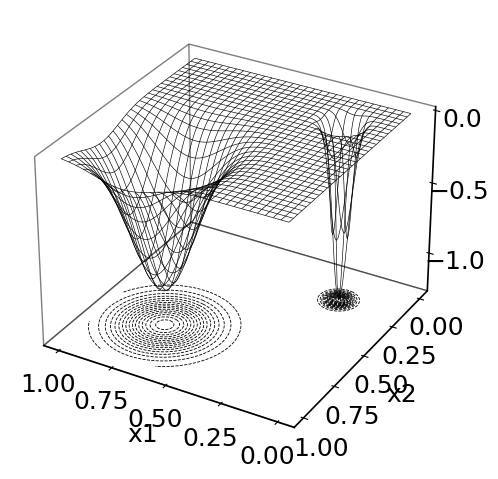

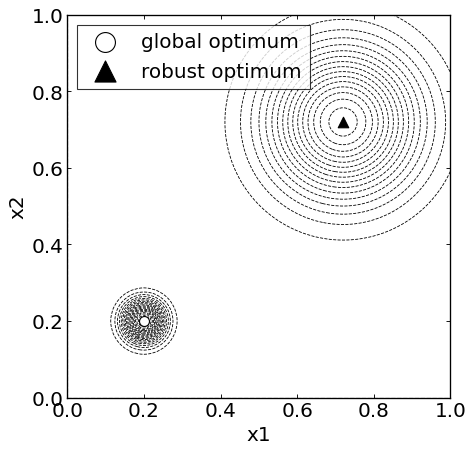

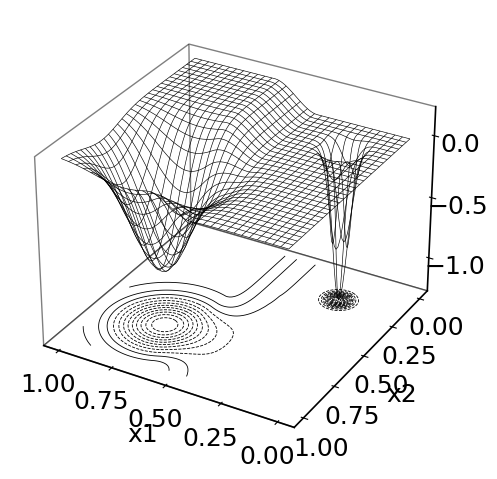

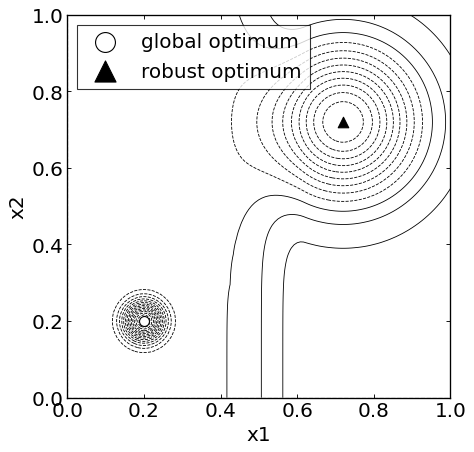

In [20]:
# -------------------- Black-and-white ridge mesh 3D projection plots --------------------
# This version intentionally avoids colormaps. It uses black wire/ridge lines on a
# white background for the 3D projection and black contour lines for the top view.


def plot_synthetic_function_3d_bw_wireframe(
    function,
    n_grid=121,
    initial_points=None,
    exploration_points=None,
    x_initial=None,
    y_initial=None,
    wire_stride=4,
    contour_levels=20,
):
    """Plot a black-and-white 3D ridge mesh and 2D contour projection.

    The figure uses no colormap: the surface is represented by black mesh lines,
    the z-plane projection is drawn as black contour lines, and the 2D view is a
    white-background contour map with optional BO search trace markers.
    """
    x1 = np.linspace(0.0, 1.0, n_grid)
    x2 = np.linspace(0.0, 1.0, n_grid)
    X1, X2 = np.meshgrid(x1, x2)
    X = np.stack([X1, X2], axis=-1)
    Z = function(X)

    z_min = float(np.min(Z))
    z_max = float(np.max(Z))

    fig3d = plt.figure(figsize=(7, 5))
    ax3d = fig3d.add_subplot(111, projection="3d", elev=30, azim=120)
    ax3d.plot_wireframe(
        X1,
        X2,
        Z,
        rstride=wire_stride,
        cstride=wire_stride,
        color="black",
        linewidth=0.45,
    )
    ax3d.contour(
        X1,
        X2,
        Z,
        zdir="z",
        offset=z_min,
        levels=contour_levels,
        colors="black",
        linewidths=0.6,
    )
    ax3d.set_xlabel("x1")
    ax3d.set_ylabel("x2")
    ax3d.set_zlim(z_min, z_max)
    ax3d.xaxis.pane.set_facecolor("white")
    ax3d.yaxis.pane.set_facecolor("white")
    ax3d.zaxis.pane.set_facecolor("white")
    ax3d.xaxis.pane.set_edgecolor("k")
    ax3d.yaxis.pane.set_edgecolor("k")
    ax3d.zaxis.pane.set_edgecolor("k")
    ax3d.xaxis.pane.set_linewidth(1)
    ax3d.yaxis.pane.set_linewidth(1)
    ax3d.zaxis.pane.set_linewidth(1)
    ax3d.grid(False)
    plt.tight_layout()

    fig2d, ax2d = plt.subplots(1, 1, figsize=(8, 6), dpi=80)
    ax2d.contour(
        X1,
        X2,
        Z,
        levels=contour_levels,
        colors="black",
        linewidths=0.75,
    )
    ax2d.set_xlabel("x1")
    ax2d.set_ylabel("x2")
    ax2d.set_aspect("equal", adjustable="box")
    ax2d.set_facecolor("white")
    ax2d.axhline(0, color="black", linestyle="--", linewidth=1.0)
    ax2d.axvline(0, color="black", linestyle="--", linewidth=1.0)

    if initial_points is None and x_initial is not None and y_initial is not None:
        initial_points = np.column_stack((np.ravel(x_initial), np.ravel(y_initial)))
    initial_points = _as_2d_points(initial_points)
    exploration_points = _as_2d_points(exploration_points)
    trace_parts = [points for points in (initial_points, exploration_points) if points is not None]
    if trace_parts:
        trace_points = np.vstack(trace_parts)
        ax2d.plot(
            trace_points[:, 0],
            trace_points[:, 1],
            color="black",
            linestyle=":",
            linewidth=0.8,
            label="search trajectory",
            zorder=4,
        )
    if initial_points is not None:
        ax2d.scatter(
            initial_points[:, 0],
            initial_points[:, 1],
            facecolors="white",
            edgecolors="black",
            s=35,
            marker="o",
            label="initial points",
            zorder=5,
        )
    if exploration_points is not None:
        ax2d.scatter(
            exploration_points[:, 0],
            exploration_points[:, 1],
            color="black",
            s=35,
            marker="o",
            label="exploration points",
            zorder=5,
        )
    plt.tight_layout()

    return (fig3d, ax3d), (fig2d, ax2d)


(fig3d, ax3d), (fig2d, ax2d) = plot_synthetic_function_3d_bw_wireframe(lib_debug.f1)
ax2d.scatter(
    0.2000000,
    0.2000000,
    facecolors="white",
    edgecolors="black",
    s=80,
    marker="o",
    label="global optimum",
    zorder=6,
)
ax2d.scatter(
    0.7200000,
    0.7200000,
    color="black",
    s=90,
    marker="^",
    label="robust optimum",
    zorder=6,
)
ax2d.legend(loc="upper left")
plt.show()

# To plot f2 or f3 in the same monochrome style, comment-in one of the examples below.
(fig3d, ax3d), (fig2d, ax2d) = plot_synthetic_function_3d_bw_wireframe(lib_debug.f2)
ax2d.scatter(0.2000000, 0.2000000, facecolors="white", edgecolors="black", s=80, marker="o", label="global optimum", zorder=6)
ax2d.scatter(0.7200000, 0.7200000, color="black", s=90, marker="^", label="robust optimum", zorder=6)
ax2d.legend(loc="upper left")
plt.show()
#
# (fig3d, ax3d), (fig2d, ax2d) = plot_synthetic_function_3d_bw_wireframe(lib_debug.f3)
# ax2d.scatter(0.3542716, 0.5000000, facecolors="white", edgecolors="black", s=80, marker="o", label="global optimum", zorder=6)
# ax2d.scatter(0.7199787, 0.5000000, color="black", s=90, marker="^", label="robust optimum", zorder=6)
# ax2d.legend(loc="upper left")
# plt.show()


--- Strategy Selected: robust_lcb_J ---
--- Function Selected: f2 (d=2) ---
--- Starting Optimization Loop (30 iterations) ---
Iter  | Best y       | New y        | acq value     
------------------------------------------------------------
1     | -0.484449    | -0.117002    | -0.941444     
2     | -0.782561    | -0.782561    | -0.921617     
3     | -0.782561    | -0.457550    | -0.985267     
4     | -0.782561    | -0.329188    | -0.978915     
5     | -0.782561    | -0.000000    | -0.943164     
6     | -0.782561    | -0.000000    | -0.891740     
7     | -0.782561    | -0.000000    | -0.876553     
8     | -0.782561    | -0.000000    | -0.882370     
9     | -0.782561    | -0.631991    | -0.893221     
10    | -0.782561    | -0.000423    | -0.873768     
11    | -0.782561    | 0.199225     | -0.878425     
12    | -0.782561    | 0.189222     | -0.857527     
13    | -0.782561    | -0.003171    | -0.852431     
14    | -0.782561    | 0.121431     | -0.835624     
15    | -0.906031

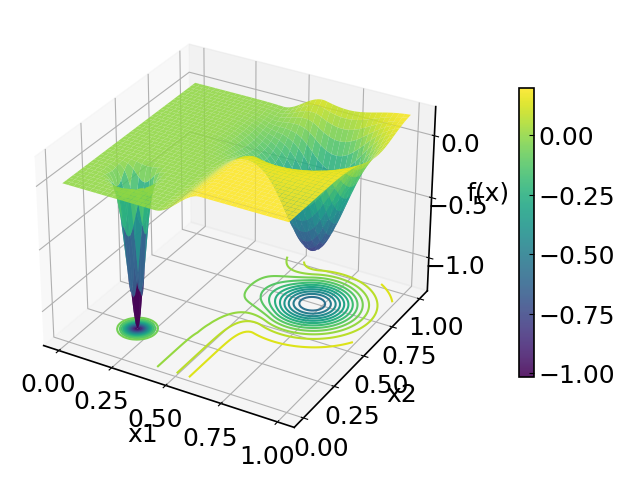

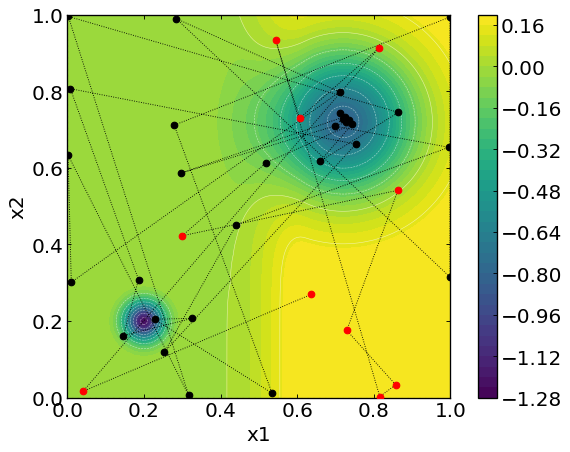

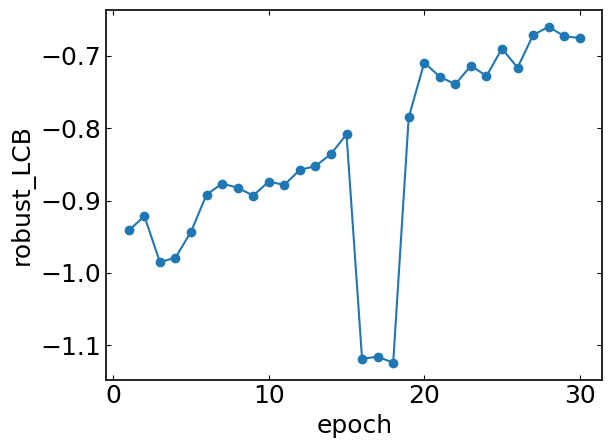

In [27]:
# -------------------- robust LCB on J(x) Bayesian Optimization --------------------
# This notebook is intentionally minimal: it only runs robust LCB on J(x).
# sEI / DGSM / StableOpt / AIRBO / uGP-UCB / USeMO / Unscented BO / CVaR /
# mean-variance robust objectives are not used here.

# -------------------- 1. Synthetic function switch --------------------
# Switch the synthetic function by comment-in / comment-out.
# Keep the variable names below unchanged when changing problems.

# f_true = lib_debug.f1
# function_name = "f1"
# bounds = np.array([[0.0, 1.0], [0.0, 1.0]])
# d = 2
# gamma = 40.0

f_true = lib_debug.f2
function_name = "f2"
bounds = np.array([[0.0, 1.0], [0.0, 1.0]])
d = 2
gamma = 40.0

# f_true = lib_debug.f3
# function_name = "f3"
# bounds = np.array([[0.0, 1.0], [0.0, 1.0]])
# d = 2
# gamma = 40.0

Sigma = np.diag((0.05 * (bounds[:, 1] - bounds[:, 0])) ** 2)
canonical_name = function_name
lower_bounds = bounds[:, 0]
upper_bounds = bounds[:, 1]

# -------------------- 2. Default experiment settings --------------------
random_seed = 0
rng = np.random.default_rng(random_seed)
noise_std = 0.0
noise_var = noise_std ** 2
n_initial = 5 * d
n_iter = 30
n_perturb_acq = 64
n_perturb_validation = 512
kappa = 1.0
n_candidates = 2000 if d <= 2 else 5000

STRATEGY = "robust_lcb_J"  # or "LCB" by comment-switching the acquisition block below
print(f"--- Strategy Selected: {STRATEGY} ---")
print(f"--- Function Selected: {canonical_name} (d={d}) ---")

# -------------------- 3. Initialization --------------------
X_train = rng.uniform(lower_bounds, upper_bounds, size=(n_initial, d))
y_train = f_true(X_train).reshape(-1, 1)
if noise_std > 0:
    y_train = y_train + rng.normal(0.0, noise_std, size=y_train.shape)
X_initial = X_train.copy()
y_initial = y_train.copy()
exploration_points = []

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<12} | {'New y':<12} | {'acq value':<14}")
print("-" * 60)

x_robust_lcb_J = None
robust_lcb_history = []
for i in range(n_iter):
    # 1. Fit GP to the current nominal observations D={(X, y)}.
    gp = lib_debug.KernelGPRegressor(
        kernel=lib_debug.rbf_kernel,
        gamma=gamma,
        noise_var=noise_var,
    ).fit(X_train, y_train)

    # 2. Acquisition switch. Comment-out one block and comment-in the other.
    # robust LCB on J(x)
    x_next, acq_value = lib_debug.optimize_robust_lcb_by_random_search(
        gp,
        Sigma,
        bounds,
        rng,
        n_perturb=n_perturb_acq,
        kappa=kappa,
        n_candidates=n_candidates,
    )

    # standard LCB
    # x_next, acq_value = lib_debug.optimize_lcb_by_random_search(
    #     gp,
    #     bounds,
    #     rng,
    #     kappa=kappa,
    #     n_candidates=n_candidates,
    # )

    # 3. Observe the nominal black-box function once at x_next.
    #    We do not observe f_true(x_next + delta) in this PoC.
    y_next = f_true(x_next.reshape(1, -1)).reshape(1, 1)
    if noise_std > 0:
        y_next = y_next + rng.normal(0.0, noise_std, size=(1, 1))

    # 4. Update data.
    X_train = np.vstack([X_train, x_next])
    y_train = np.vstack([y_train, y_next])
    x_robust_lcb_J = x_next
    exploration_points.append(x_next.copy())
    robust_lcb_history.append(acq_value)

    print(
        f"{i + 1:<5} | {np.min(y_train):<12.6f} | "
        f"{y_next.item():<12.6f} | {acq_value:<14.6f}"
    )

# -------------------- 5. Final surrogate robust mean validation --------------------
gp = lib_debug.KernelGPRegressor(
    kernel=lib_debug.rbf_kernel,
    gamma=gamma,
    noise_var=noise_var,
).fit(X_train, y_train)

best_idx_final = int(np.argmin(y_train))
best_observed_x = X_train[best_idx_final]
best_observed_y = float(y_train[best_idx_final, 0])

validation = lib_debug.validate_surrogate_robust_mean(
    {
        "robust_lcb_J": x_robust_lcb_J,
    },
    gp,
    Sigma,
    bounds,
    n_mc=n_perturb_validation,
    rng=rng,
    use_cov=True,
)
robust_best = min(validation, key=lambda name: validation[name]["posterior_robust_mean"])

# -------------------- 6. Required summaries --------------------
print("\nBO summary")
print(f"function name: {canonical_name}")
print(f"dimension d: {d}")
print(f"bounds:\n{bounds}")
print(f"n_initial: {n_initial}")
print(f"n_iter: {n_iter}")
print(f"n_perturb_acq: {n_perturb_acq}")
print(f"kappa: {kappa}")
print(f"Sigma:\n{Sigma}")
print(f"best observed y: {best_observed_y:.6f}")
print(f"best observed x: {best_observed_x}")
print(f"final robust_lcb_J recommended x: {x_robust_lcb_J}")

print("\nvalidation summary")
header = (
    f"{'candidate':<18} {'nominal_posterior_mean':>24} "
    f"{'nominal_posterior_std':>23} {'posterior_robust_mean':>24} "
    f"{'posterior_robust_std':>23} {'posterior_mu_sample_std':>25}"
)
print(header)
print("-" * len(header))
for candidate, stats in validation.items():
    print(
        f"{candidate:<18} {stats['nominal_posterior_mean']:>24.6f} "
        f"{stats['nominal_posterior_std']:>23.6f} "
        f"{stats['posterior_robust_mean']:>24.6f} "
        f"{stats['posterior_robust_std']:>23.6f} "
        f"{stats['posterior_mu_sample_std']:>25.6f}"
    )
print(f"\nrobust best by posterior_robust_mean: {robust_best}")

# -------------------- 7. Overplot final robust LCB J recommendation --------------------
# Save the final robust LCB J recommendation and overlay it on the selected 2D projection.
final_robust_lcb_J_recommendation = {
    "function_name": canonical_name,
    "x": np.asarray(x_robust_lcb_J, dtype=float).copy(),
    "y": float(f_true(np.asarray(x_robust_lcb_J, dtype=float).reshape(1, -1))[0]),
}
print("\nfinal robust LCB J recommendation")
print(f"function name: {final_robust_lcb_J_recommendation['function_name']}")
print(f"x: {final_robust_lcb_J_recommendation['x']}")
print(f"y: {final_robust_lcb_J_recommendation['y']:.6f}")

fig, ax = plot_synthetic_function_3d(
    f_true,
    initial_points=X_initial,
    exploration_points=np.asarray(exploration_points),
)
#ax.legend(loc="upper left")
plt.show()

# -------------------- 8. robust_LCB tracking plot --------------------
epochs = np.arange(1, len(robust_lcb_history) + 1)
fig, ax = plt.subplots()
ax.plot(epochs, robust_lcb_history, marker="o")
ax.set_xlabel("epoch")
ax.set_ylabel("robust_LCB")
plt.show()
